# 08 - Curse of Dimensionality


---

In the previous notebook, we learned IVF.

IVF uses clustering to reduce the search space.

But another challenge remains.

Modern embedding models produce vectors with hundreds or even thousands of dimensions.

Examples:

- MiniLM → 384 dimensions
- BGE → 768 dimensions
- OpenAI text-embedding-3-small → 1536 dimensions

Searching efficiently in such high-dimensional spaces is difficult.

This problem is known as the **Curse of Dimensionality**.

##  History

Early search algorithms worked well in:

- 2 dimensions
- 3 dimensions
- 10 dimensions

As Machine Learning evolved,

embeddings became much larger.

Now vectors commonly have:

- 384 dimensions
- 768 dimensions
- 1024 dimensions
- 1536 dimensions

Researchers discovered that many traditional search algorithms became inefficient.

This challenge became known as the **Curse of Dimensionality**.

##  Think Like a Researcher

Imagine finding your friend.

One room

↓

Easy.

One building

↓

Still manageable.

One city

↓

Harder.

Now imagine searching the entire world.

The search space becomes enormous.

Exactly the same thing happens with vectors.

As dimensions increase,

the search space grows dramatically.

In [1]:
import numpy as np

vector_2d = np.array([2,3])

vector_3d = np.array([2,3,5])

vector_5d = np.array([2,3,5,8,10])

print(vector_2d)
print(vector_3d)
print(vector_5d)

[2 3]
[2 3 5]
[ 2  3  5  8 10]


## Observation

Each value in a vector represents one dimension.

Example

```
[0.21, -0.84, 0.52]
```

↓

3 dimensions

Modern embedding models often produce hundreds or thousands of dimensions.

In [2]:
models = {
    "MiniLM":384,
    "BGE Base":768,
    "OpenAI text-embedding-3-small":1536
}

for model,dimension in models.items():
    print(model,"->",dimension)

MiniLM -> 384
BGE Base -> 768
OpenAI text-embedding-3-small -> 1536


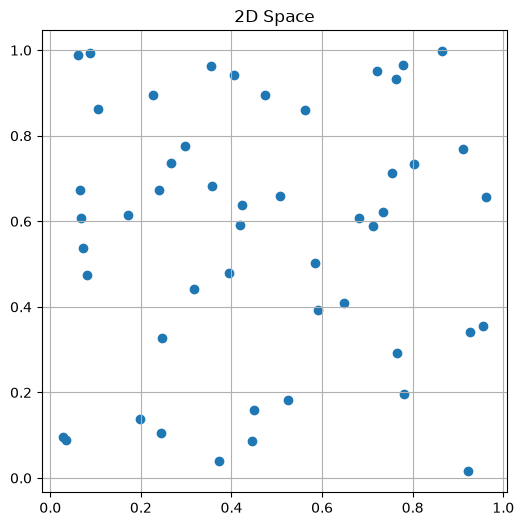

In [5]:
import matplotlib.pyplot as plt

points = np.random.rand(50,2)

plt.figure(figsize=(6,6))

plt.scatter(points[:,0],points[:,1])

plt.title("2D Space")

plt.grid()

plt.show()

## Think

In 2D,

we can easily visualize all points.

Can we visualize

384 dimensions?

No.

Humans cannot directly visualize such spaces.

We rely on mathematics instead.

In [6]:
np.random.seed(42)

points = np.random.rand(1000,2)

query = np.random.rand(2)

distances = np.linalg.norm(points-query,axis=1)

print("Minimum distance:",distances.min())
print("Maximum distance:",distances.max())

Minimum distance: 0.004600201123151604
Maximum distance: 1.026834775647763


In [7]:
points = np.random.rand(1000,100)

query = np.random.rand(100)

distances = np.linalg.norm(points-query,axis=1)

print("Minimum distance:",distances.min())
print("Maximum distance:",distances.max())

Minimum distance: 3.1927819179071273
Maximum distance: 4.746287180808108


## Observation

As dimensions increase,

the nearest and farthest points become more similar in distance.

This makes distinguishing neighbors more difficult.

This phenomenon is one aspect of the Curse of Dimensionality.

## Why is this a Problem?

Many search algorithms rely on the idea that nearby points are much closer than faraway points.

In high dimensions,

that distinction becomes weaker.

Searching efficiently becomes much harder.

## KDTree Limitation

KDTree divides space into regions.

This works well in low dimensions.

As dimensions increase,

the number of regions grows rapidly,

and KDTree loses much of its efficiency.

This is why KDTree is usually not chosen for modern embedding vectors.

## Modern Embeddings

Typical dimensions today:

MiniLM

↓

384

BGE

↓

768

OpenAI

↓

1536

Searching these efficiently requires specialized ANN algorithms.

## Applications

The Curse of Dimensionality affects:

- Vector Databases
- Recommendation Systems
- Image Retrieval
- Audio Search
- Semantic Search
- RAG Systems

## How Researchers Solved It

Instead of relying on traditional search methods,

researchers developed:

- IVF
- LSH
- HNSW
- Product Quantization

These methods are designed to work well with high-dimensional embeddings.

## Summary

Today I learned:

- What a dimension is
- Why embeddings have many dimensions
- What the Curse of Dimensionality means
- Why traditional search structures struggle
- Why ANN methods are important

##  Think Like a Researcher

Now we understand why high-dimensional search is challenging.

Researchers first tried dividing the search space into regions using a tree structure.

This idea became the **KDTree**.

It works well for low-dimensional data,

but, as we just learned,

its performance decreases as dimensionality grows.